# Do High-K/D Players Actually Win More?
### Call of Duty World League 2019 (Black Ops 4) — SQL Analysis

**Question:** In pro Call of Duty, do players with a high kill/death ratio (K/D) actually win more, or do other stats matter more?

**Data:** Player-by-map box scores from the 2019 CWL season (Black Ops 4). Each row is one player's stats on one map.

**Data source and credit:** `BO4_Full.csv` comes from Jpkrez's [cwl-stats](https://github.com/jpkrez/cwl-stats) repository ([file](https://github.com/jpkrez/cwl-stats/tree/main/2019-BO4)), a public archive of CWL player stats that he collected while working for MLG from 2016 to 2019. Thanks to Jpkrez for sharing it for public research and analysis.

**Tools:** Python, pandas, SQLite (SQL), Matplotlib

## 1. Load the data into a SQL database

The raw column names have dots in them (like `win.` and `hill.time..s.`), which are awkward in SQL. This step converts them to clean `snake_case` names, then loads everything into a SQLite table called `games`.

In [17]:
import pandas as pd, sqlite3, re
import matplotlib.pyplot as plt

df = pd.read_csv("BO4_Full.csv", low_memory=False)
df = df.rename(columns={"Unnamed: 0": "row_id", "X...": "plus_minus"})
df.columns = [re.sub(r"\.+", "_", c).strip("_").lower() for c in df.columns]

conn = sqlite3.connect("cwl_bo4.db")
df.to_sql("games", conn, if_exists="replace", index=False)

def sql(query):
    return pd.read_sql(query, conn)

print(df.shape)
print(df.columns.tolist())

(22301, 64)
['row_id', 'match_id', 'series_id', 'duration_s', 'mode', 'map', 'team', 'win', 'score', 'player', 'kills', 'deaths', 'plus_minus', 'k_d', 'kills_per_10min', 'deaths_per_10min', 'player_score', 'player_spm', 'damage_dealt', 'event', 'end_time', 'ekia', 'assists', 'headshots', 'suicides', 'team_kills', 'team_deaths', 'kills_stayed_alive', 'hits', 'shots', 'accuracy', 'num_lives', 'time_alive_s', 'avg_time_per_life_s', 'fave_weapon', 'fave_specialist', 'fave_scorestreaks', 'hill_time_s', 'hill_captures', 'hill_defends', 'snd_rounds', 'snd_firstbloods', 'snd_firstdeaths', 'snd_survives', 'bomb_pickups', 'bomb_plants', 'bomb_defuses', 'bomb_sneak_defuses', 'snd_1_kill_round', 'snd_2_kill_round', 'snd_3_kill_round', 'snd_4_kill_round', 'ctrl_rounds', 'ctrl_firstbloods', 'ctrl_firstdeaths', 'ctrl_captures', 'x2_piece', 'x3_piece', 'x4_piece', 'x4_streak', 'x5_streak', 'x6_streak', 'x7_streak', 'x8_streak']


## 2. Data-quality checks

Before answering the question, check what the data can and can't support.

**Check 1: Which events have the detailed stats?**

In [19]:
sql("""
SELECT event,
       COUNT(*)                                   AS rows,
       ROUND(AVG(assists IS NOT NULL) * 100)      AS pct_with_assists,
       ROUND(AVG(duration_s IS NOT NULL) * 100)   AS pct_with_duration,
       ROUND(AVG(hill_time_s IS NOT NULL) * 100)  AS pct_with_hill_time
FROM games
GROUP BY event
ORDER BY rows DESC
""")

,event,rows,pct_with_assists,pct_with_duration,pct_with_hill_time
0,Pro League,7160,97.0,100.0,100.0
1,PLQ,3170,100.0,100.0,100.0
2,Champs,2970,100.0,100.0,100.0
3,Vegas,2620,0.0,61.0,0.0
4,Fort Worth,1831,98.0,100.0,98.0
5,London,1810,100.0,100.0,83.0
6,Anaheim,1800,100.0,100.0,100.0
7,Miami,940,99.0,100.0,100.0


**Check 2: Is the original `k_d` column usable?**

In [21]:
sql("""
SELECT k_d, kills, deaths, event, COUNT(*) AS n
FROM games
WHERE k_d NOT GLOB '[0-9]*'
GROUP BY k_d, kills, deaths, event
""")

,k_d,kills,deaths,event,n
0,#DIV/0!,None,None,London,20


**Check 3: Is the `accuracy` column usable?**

In [23]:
sql("""
SELECT accuracy = '0.0%' AS is_zero, COUNT(*) AS n
FROM games
WHERE accuracy IS NOT NULL
GROUP BY is_zero
""")

,is_zero,n
0,0,5
1,1,19105


**Check 4: Does `match_id` uniquely identify a map?** A map should have 10 rows (5 players per team).

In [25]:
sql("""
SELECT match_id, COUNT(*) AS rows
FROM games
GROUP BY match_id
HAVING COUNT(*) > 10
ORDER BY rows DESC
LIMIT 5
""")

,match_id,rows
0,1,50
1,0,31
2,3,30
3,2,30
4,OpTicGaming_Splyce_Gridlock_Control_3,20


In [26]:
# Try a combined key instead: event + series_id + match_id
sql("""
SELECT event, series_id, match_id, COUNT(*) AS players
FROM games
GROUP BY event, series_id, match_id
HAVING COUNT(*) <> 10
""")

,event,series_id,match_id,players
0,Fort Worth,champs-losers-5-1,0,11


**Takeaways from the data checks**

- **Vegas is missing key stats.** It has no assists or hill time at all, and duration is missing for about 40% of its rows. Because of that, I left the Vegas event out of the analysis.
- **The original `k_d` column can't be trusted.** 20 London rows have no kills or deaths recorded and show a spreadsheet error (`#DIV/0!`) instead of a K/D. From here on, I calculate K/D myself from kills and deaths.
- **Accuracy is unusable.** 19,105 of the 19,110 rows with an accuracy value show 0.0%, so I don't use it.
- **`match_id` alone doesn't identify a map.** The same IDs repeat across events and series, so I identify each map by event + series + match instead. With that key, every map has 10 players except one Fort Worth map with 11, which is too small to affect the results.

## 3. Team level: does the team with the higher K/D win the map?

For each map, compare the two teams' combined K/D and check whether the higher-K/D team won.

In [29]:
team_kd = sql("""
WITH team_maps AS (
    SELECT event, series_id, match_id, mode, team,
           MAX(win) = 'W'                           AS won,
           SUM(kills) * 1.0 / NULLIF(SUM(deaths), 0) AS team_kd
    FROM games
    WHERE event <> 'Vegas'
    GROUP BY event, series_id, match_id, mode, team
)
SELECT a.mode,
       COUNT(*) AS maps,
       ROUND(AVG(CASE WHEN a.team_kd > b.team_kd THEN a.won ELSE b.won END) * 100, 1)
           AS pct_higher_kd_team_won
FROM team_maps a
JOIN team_maps b
  ON  a.event = b.event
  AND a.series_id = b.series_id
  AND a.match_id = b.match_id
  AND a.team < b.team
WHERE a.team_kd <> b.team_kd
GROUP BY a.mode
""")
team_kd

,mode,maps,pct_higher_kd_team_won
0,Control,495,91.1
1,Hardpoint,819,91.3
2,Search & Destroy,634,91.6


**What this does and doesn't prove**

The team with the higher combined K/D won about 91% of maps in every mode (91.1% in Control, 91.3% in Hardpoint, 91.6% in Search & Destroy). That's a strong connection, but it doesn't prove that K/D *causes* wins. The team that's winning a map is usually the one controlling the fights, so it naturally racks up more kills and fewer deaths. A high K/D is partly a *result* of winning, not only a reason for it, so I need to look at other stats to see what actually separates winning players.

## 4. Player level: which stats line up with winning, by mode?

Build one row per player per game mode, with their win rate and their stats. Rates are per 10 minutes or per round, so players who played more or longer maps are compared fairly. Only players with at least 20 maps in a mode are included, so a few lucky maps don't skew the results.

In [32]:
players = sql("""
SELECT player, mode,
       COUNT(*)                                                   AS maps,
       AVG(win = 'W')                                             AS win_rate,
       SUM(kills) * 1.0 / NULLIF(SUM(deaths), 0)                  AS kd,
       SUM(damage_dealt) * 600.0 / SUM(duration_s)                AS damage_per_10min,
       SUM(assists) * 600.0 / SUM(duration_s)                     AS assists_per_10min,
       AVG(hill_time_s)                                           AS hill_time_per_map,
       SUM(snd_firstbloods) * 1.0 / NULLIF(SUM(snd_rounds), 0)    AS firstblood_rate,
       SUM(snd_firstdeaths) * 1.0 / NULLIF(SUM(snd_rounds), 0)    AS firstdeath_rate,
       SUM(snd_survives) * 1.0 / NULLIF(SUM(snd_rounds), 0)       AS survive_rate,
       SUM(ctrl_captures) * 1.0 / NULLIF(SUM(ctrl_rounds), 0)     AS captures_per_round
FROM games
WHERE event <> 'Vegas'
GROUP BY player, mode
HAVING COUNT(*) >= 20
""")
players.groupby("mode").size()

mode
Control             94
Hardpoint           99
Search & Destroy    97
dtype: int64

Now measure how strongly each stat relates to win rate within each mode. A correlation of 1 means they rise together perfectly, 0 means no relationship, and a negative number means one goes up as the other goes down.

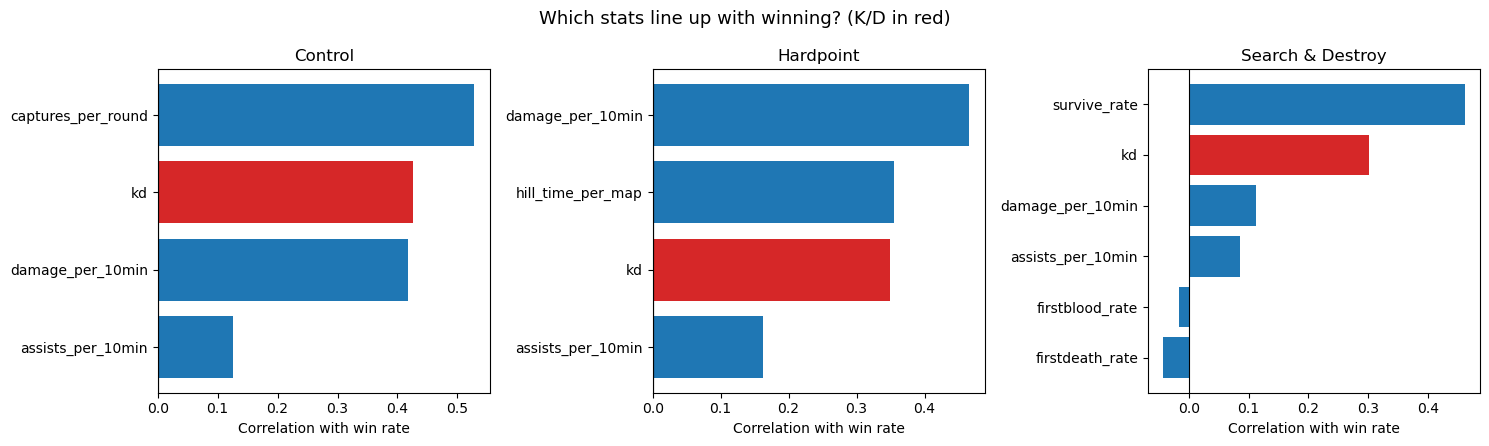

,Control,Hardpoint,Search & Destroy
assists_per_10min,0.13,0.16,0.09
captures_per_round,0.53,NaN,NaN
damage_per_10min,0.42,0.47,0.11
firstblood_rate,NaN,NaN,-0.02
firstdeath_rate,NaN,NaN,-0.04
hill_time_per_map,NaN,0.35,NaN
kd,0.43,0.35,0.30
survive_rate,NaN,NaN,0.46


In [34]:
stat_cols = [c for c in players.columns if c not in ("player", "mode", "maps", "win_rate")]
corrs = {}
for mode, group in players.groupby("mode"):
    stats = group[stat_cols]
    stats = stats.loc[:, stats.nunique() > 1]   # skip stats that don't apply to this mode
    corrs[mode] = stats.corrwith(group["win_rate"]).dropna().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (mode, c) in zip(axes, corrs.items()):
    colors = ["#d62728" if name == "kd" else "#1f77b4" for name in c.index]
    ax.barh(c.index, c.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(mode)
    ax.set_xlabel("Correlation with win rate")
fig.suptitle("Which stats line up with winning? (K/D in red)", fontsize=13)
plt.tight_layout()
plt.show()

pd.DataFrame(corrs).round(2)

**Is K/D the stat most tied to winning?**

No. In every mode, a different stat lines up with winning at least as strongly as K/D:

- **Control:** Captures per round (0.53) beats K/D (0.43), and damage per 10 minutes (0.42) is about even with K/D. Control is won by taking zones, so the players who capture objectives are the ones driving round wins.
- **Hardpoint:** Damage per 10 minutes (0.47) beats K/D (0.35), and hill time ties K/D (0.35). Damage counts a player's contribution even when a teammate gets the final kill, which fits a mode built around fighting over a shared hill.
- **Search & Destroy:** Survive rate (0.46) beats K/D (0.30). With only one life per round, staying alive keeps your team up a player. Surprisingly, first-blood rate had almost no relationship with winning (−0.02).

Assists were weakly tied to winning in every mode (0.09–0.16).

## 5. A closer look: the top K/D players in Hardpoint

Do the players with the best K/D also have the best win rates? This also shows which teams they played for.

In [62]:
top_kd = sql("""
SELECT player,
       GROUP_CONCAT(DISTINCT team)                         AS teams,
       COUNT(*)                                            AS maps,
       ROUND(SUM(kills) * 1.0 / NULLIF(SUM(deaths), 0), 2) AS kd,
       ROUND(AVG(win = 'W') * 100, 1)                      AS win_pct
FROM games
WHERE event <> 'Vegas' AND mode = 'Hardpoint'
GROUP BY player
HAVING COUNT(*) >= 20
ORDER BY kd DESC
LIMIT 10
""")
top_kd.index = range(1, len(top_kd) + 1)   # number the rows 1-10 instead of 0-9
top_kd.index.name = "rank"
top_kd

,player,teams,maps,kd,win_pct
rank,,,,,
1,Dashy,OpTic Gaming,75,1.30,61.3
2,Octane,100 Thieves,102,1.27,73.5
3,Skrapz,"Red Reserve,FaZe Clan",96,1.24,63.5
4,Temp,Splyce,85,1.17,45.9
5,Simp,eUnited,75,1.17,66.7
6,Skyz,"UYU,Excelerate,Elevate,Luminosity",92,1.16,55.4
7,Cellium,FaZe Clan,68,1.16,63.2
8,Brack,"Midnight,Excelerate,Denial,Luminosity,Units",85,1.16,55.3
9,Dylan,"Team Sween,Reciprocity",90,1.15,51.1


**High K/D, average win rate**

Yes. Temp ranks 4th in Hardpoint K/D (1.17) but won only 45.9% of his maps, the only top-10 player below 50%. Dylan (1.15 K/D) won just 51.1%. Meanwhile Octane, 2nd in K/D (1.27), had the best win rate in the top 10 at 73.5%.

A strong individual player can still lose a lot if the rest of the team doesn't win fights or play the objective. Several players on this list also switched teams during the season (Skyz played for four teams and Brack for five), so their win rates mix very different rosters.

## 6. Conclusions

Players with a high K/D do tend to win more, but K/D was never the stat most closely tied to winning in any mode. What mattered most depended on the mode: capturing zones in Control, dealing damage in Hardpoint, and staying alive in Search & Destroy. The biggest surprise was that getting the first kill of a Search & Destroy round had almost no relationship with winning. For anyone judging players, or designing a game's scoreboard, stats like captures, damage, and survival deserve as much attention as K/D.

## 7. Limitations

- **Correlation isn't causation.** Winning teams get more kills, not only the other way around.
- **Teammates matter.** A player's win rate depends on the team around them, so players on stronger teams look better.
- **Limited scope.** One season of one game (Black Ops 4), pro players only. Results may not apply to casual players or other titles.
- **Data gaps.** The Vegas event and the accuracy column couldn't be used, and one Fort Worth map lists 11 players.
- **Small, mixed samples.** Only players with 20+ maps in a mode are included (94–99 players per mode), several players changed teams mid-season, and the correlations are moderate (0.30–0.53), not near-perfect.